# Generative model for galaxy SEDs

This notebook evaluates the trained probabilistic autoencoder (PAE) from [Frediani et al. (2026)](https://arxiv.org/abs/2609.26594), a generative model for normalised rest-frame galaxy spectra, redshifts, and luminosities.

The two networks (AE and flow) are trained by `train_AE.py` and `train_flow.py`; this notebook loads the pre-trained weights and data and reproduces Figs. 2–6 of the paper.
A GPU is recommended.

In [ ]:
import numpy as np
import torch
import matplotlib as mpl
from matplotlib import pyplot as plt
import corner
import os
from sklearn.model_selection import train_test_split
from scipy.stats import norm

print('CUDA is available:',torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
FILEPATH = './' 
DATAPATH = 'datasets/'
os.chdir(FILEPATH)

import models
import util

CUDA is available: True


## Training data

First, load and preprocess the data.

The dataset contains 2,305,000 mock spectra from the GalSBI-SPS population model ($z \leq 1.55$, $m_z \leq 22$). They were previously resampled to a fixed wavelength grid of 2000 log-spaced bins from 1,000-25,000 Å.

Preprocessing:
Each spectrum is normalised by its median flux density $L^*$, and Gaussian noise is added with a fixed amplitude level equivalent to 10% of the flux.
The seeded 1M/1M/0.3M train/test/validation split is identical to the one used in training, so the test set used for all evaluations below is disjoint from the training set.

In [2]:
Z_MAX = 1.55  # redshift cut of the simulated sample
WAV = torch.logspace(np.log10(1000), np.log10(25000), 2000)  # rest-frame wavelength grid

raw_spectra = torch.load(DATAPATH+'sim_sample_sed.pt')
z = torch.load(DATAPATH+'sim_sample_z.pt')

# normalise each spectrum by its median flux density L* (in place; raw_spectra is not needed again)
luminosities = raw_spectra.median(dim=1).values
noiseless_fluxes = raw_spectra.div_(luminosities[:,None])
del raw_spectra

# add fractional Gaussian noise (sigma = 10% of the flux); the floor keeps loss weights finite
errs = (0.1 * noiseless_fluxes).clamp_(min=1e-4)
fluxes = torch.empty_like(noiseless_fluxes).normal_(generator=torch.Generator().manual_seed(151))
fluxes.mul_(errs).add_(noiseless_fluxes)   # fluxes = noiseless_fluxes + errs * N(0, 1)

# seeded train/test/val split — identical to the training scripts
idx_train, idx_test = train_test_split(torch.arange(len(fluxes)), train_size=int(1e6), random_state=151)
idx_test,  idx_val  = train_test_split(idx_test,                  train_size=int(1e6), random_state=151)
print('train:', len(idx_train), '  test:', len(idx_test), '  val:', len(idx_val))


train: 1000000   test: 1000000   val: 305000


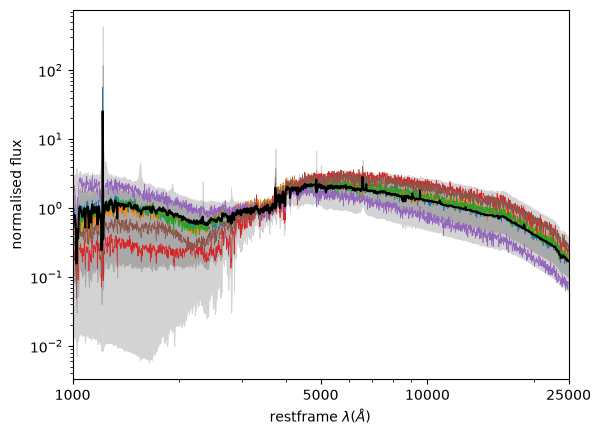

In [3]:
# population quantile bands (from a 100k subsample) + 6 random noisy spectra
q1, q2, q3, q4, q5 = torch.quantile(fluxes[:100000], torch.tensor([0.025, 0.16, 0.5, 0.84, 0.975]), dim=0)

plt.figure()
l1 = plt.plot(WAV, q3, c='k', label='median flux', zorder=10)
l2 = plt.fill_between(WAV, q1, q5, facecolor='lightgray', edgecolor='lightgray', lw=.5)
l3 = plt.fill_between(WAV, q2, q4, facecolor='darkgray', edgecolor='darkgray', lw=.5)
for i in np.random.choice(len(fluxes), size=6, replace=False):
    plt.plot(WAV,fluxes[i], lw=0.5)

plt.yscale('log'), plt.xscale('log')
plt.xlim(1000,25000)
plt.xlabel(r'restframe $\lambda (\AA)$'), plt.ylabel(r'normalised flux')
plt.xticks([1000, 5000, 10000, 25000],['1000', '5000', '10000', '25000'])
plt.show()

## Autoencoder

The AE compresses each 2000-pixel spectrum into 6 latent dimensions and reconstructs
it. Here we load a pretrained checkpoint, trained only on noisy spectra and evaluate the reconstructions on the test set (paper Sect. 3.1).

In [4]:
N_LATENT = 6

autoenc = models.build_paper_autoencoder()

# load the published AE checkpoint
autoenc = models.LAutoencoder.load_from_checkpoint(
    FILEPATH+'models/AE_n6_enc1000x500x100_ReLU_asinh-sinh_noise0.1_Adam_lr0.001_reduce_1000k_GalSBIUspec1M_restframe/version_0/best.ckpt',
    model=autoenc).to(device)

def batched(fn, x, batch_size=50_000):
    """Apply fn to x in batches on `device` without autograd; returns the concatenated result on CPU."""
    with torch.no_grad():
        return torch.cat([fn(x[i:i+batch_size].to(device)).cpu() for i in range(0, len(x), batch_size)])

def quantile_cols(x, q, chunk=200):
    """torch.quantile(x, q, dim=0) evaluated on `device` in column chunks to bound memory."""
    q = torch.as_tensor(q, dtype=x.dtype, device=device)
    return torch.cat([torch.quantile(x[:, j:j+chunk].to(device), q, dim=0).cpu() for j in range(0, x.shape[1], chunk)], dim=1)

### Example reconstruction

A single test spectrum: noisy input, ground truth, and AE reconstruction, with
residuals in units of the pixel uncertainty (top panel of Fig. 4).

==>> i: 1837966


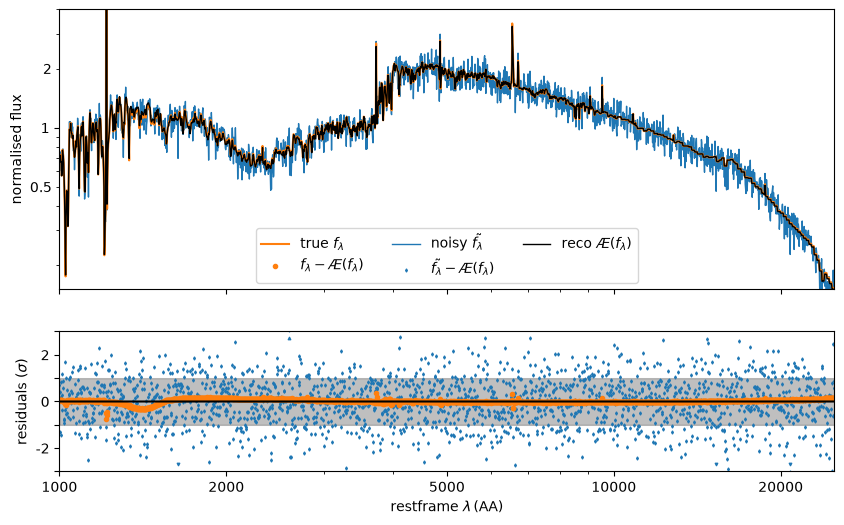

In [5]:
# plot reconstruction and residuals

# i = np.random.choice(idx_test)
i = 1837966 # this is the example spectrum shown in Fig. 4 of the paper
print(f"==>> i: {i}")

preds         = autoenc(fluxes[i].to(device)).squeeze(0).detach().cpu()
residuals     = (fluxes[i] - preds) / (errs[i])
raw_residuals = (noiseless_fluxes[i] - preds).flatten() / errs[i]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[2, 1])
l1, = ax1.plot(WAV, (fluxes[i]), color='tab:blue', lw=1.)
l2, = ax1.plot(WAV, noiseless_fluxes[i], color='tab:orange', lw=1.5)
l3, = ax1.plot(WAV, preds.numpy(), color='black', lw=1.)

ax1.set_xscale('log'), ax1.set_yscale('log')
ax1.set_ylim(1.5e-1, 4e0)
ax1.set_yticks([1], ['1'])
ax1.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 2, 3, 4], ['']*3 + ['0.5'] + ['']*4 + ['2'] + ['']*2, minor=True)
ax1.set_ylabel(r'normalised flux')

# plot residuals
s1 = ax2.scatter(WAV, residuals, color='tab:blue', marker='d', s=2)
s2 = ax2.scatter(WAV, raw_residuals, color='tab:orange', marker='.')
l4 = ax2.plot(WAV, np.zeros_like(WAV), color='k', linestyle='-')
l5 = ax2.fill_between(WAV, -1, 1, color='gray', alpha=0.5, zorder=-1)
res_max = 3
ax2.scatter(WAV[residuals>res_max], res_max*0.9*np.ones_like(residuals[residuals>res_max]),
            color='tab:blue', marker='^', s=3)
ax2.scatter(WAV[residuals<-res_max], -res_max*0.9*np.ones_like(residuals[residuals<-res_max]), 
            color='tab:blue', marker='v', s=3)

ax2.set_yscale('linear')
ax2.set_xticks([1000, 2000, 5000, 10000, 20000],['1000','2000','5000','10000','20000'])
ax2.set_yticks([-3, -2, -1, 0, 1, 2, 3],['', -2, '', 0, '', 2, ''])
ax2.set_xlim(WAV[0], WAV[-1]), ax2.set_ylim(-res_max, res_max)
ax2.set_xlabel(r'restframe $\lambda\,(\text{\AA})$'), ax2.set_ylabel(r'residuals ($\sigma$)')

ax1.legend(loc='lower center', ncol=3,
           handles=[l2,s2,l1,s1,l3],
           labels=[r'true $f_\lambda$',r'$f_\lambda - \AE(f_\lambda)$',  r'noisy $\tilde{f_\lambda}$', 
                   r'$\tilde{f_\lambda} - \AE(f_\lambda)$',r'reco $\AE(f_\lambda)$',])
plt.show()

### Zoomed reconstructions

Same as above for a second test spectrum, zoomed into the regions around Ly$\alpha$,
the 4000 Å break, and H$\alpha$ (bottom panels of Fig. 4).

==>> i: 1600983


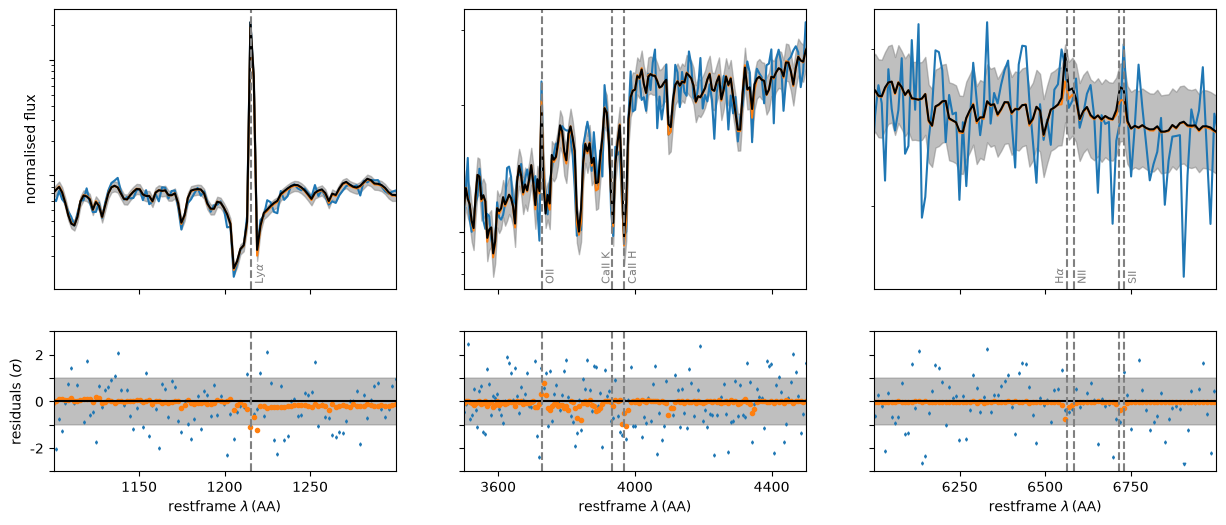

In [6]:
# plot reconstruction and residuals – 3-panel zoomed version

# i = np.random.choice(idx_test)
i = 1600983 # this is the example spectrum shown in Fig. 4 of the paper
print(f"==>> i: {i}")

preds         = autoenc(fluxes[i].to(device)).squeeze(0).detach().cpu()
residuals     = (fluxes[i] - preds) / errs[i]
raw_residuals = (noiseless_fluxes[i] - preds).flatten() / errs[i]
res_max = 3

fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharex='col', height_ratios=[2, 1])

for col, (xmin, xmax) in enumerate([(1100, 1300),(3500, 4500),(6000, 7000)]):
    ax1 = axes[0, col]
    ax2 = axes[1, col]
    mask = (WAV >= xmin-10) & (WAV <= xmax+10)
    ax1.plot(WAV[mask], fluxes[i][mask], color='tab:blue')
    ax1.plot(WAV[mask], noiseless_fluxes[i][mask], color='tab:orange', lw=1.5)
    ax1.plot(WAV[mask], preds[mask].numpy(), color='k')
    ax1.fill_between(WAV[mask], noiseless_fluxes[i][mask]-errs[i][mask], noiseless_fluxes[i][mask]+errs[i][mask], color='gray', alpha=0.5)

    ax1.set_xscale('linear'), ax1.set_yscale('log')
    ax1.set_xlim(xmin, xmax)
    ax1.set_yticklabels([])
    ax1.set_yticklabels([], minor=True)
    ax1.set_ylabel(r'normalised flux' if col == 0 else '')


    # ── Bottom panel: residuals (shared y across all columns) ─────────────────
    ax2.scatter(WAV, residuals,     color='tab:blue', marker='d', s=2)
    ax2.scatter(WAV, raw_residuals, color='tab:orange', marker='.')
    ax2.plot(WAV, np.zeros_like(WAV), color='k', linestyle='-')
    ax2.fill_between(WAV, -1, 1, color='gray', alpha=0.5, zorder=-1)

    ax2.scatter(WAV[residuals >  res_max],
                 res_max * 0.9 * np.ones_like(residuals[residuals >  res_max]),
                color='tab:blue', marker='^', s=3)
    ax2.scatter(WAV[residuals < -res_max],
                -res_max * 0.9 * np.ones_like(residuals[residuals < -res_max]),
                color='tab:blue', marker='v', s=3)

    ax2.set_yscale('linear')
    ax2.set_xticks([1150,1200,1250,3600,4000,4400,6250,6500,6750],[1150,1200,1250,3600,4000,4400,6250,6500,6750])
    ax2.set_yticks([-3, -2, -1, 0, 1, 2, 3],['', -2, '', 0, '', 2, ''] if col == 0 else [])
    ax2.set_xticklabels([], minor=True)
    ax2.set_xlim(xmin, xmax), ax2.set_ylim(-res_max, res_max)
    ax2.set_xlabel(r'restframe $\lambda\,(\text{\AA})$'), ax2.set_ylabel(r'residuals ($\sigma$)' if col == 0 else '')

def plt_line_features(lam, col, name, halignment='left'):
    axes[0,col].axvline(lam, color='gray', linestyle='--')
    axes[1,col].axvline(lam, color='gray', linestyle='--')
    axes[0,col].text(lam + (axes[0,col].get_xlim()[1] - axes[0,col].get_xlim()[0]) * 0.01 if halignment=='left' else lam,
                     axes[0,col].get_ylim()[0] * (axes[0,col].get_ylim()[1] / axes[0,col].get_ylim()[0]) ** 0.02,
                     name, rotation=90, verticalalignment='bottom', horizontalalignment=halignment, color='gray', fontsize=8)

plt_line_features(1215.670, 0, r'Ly$\alpha$')
plt_line_features((3726.032+3728.815)/2, 1, r'OII')
plt_line_features(3933.66 , 1, r'CaII K', halignment='right')
plt_line_features(3968.47 , 1, r'CaII H')
plt_line_features(6562.819, 2, r'H$\alpha$', halignment='right')
plt_line_features(6583.460 , 2, r'NII')
plt_line_features(6716.440, 2, r'')
plt_line_features(6730.810, 2, r'SII')
plt.show()

### Residuals across wavelength

Median and 68%/95% quantile bands of the reconstruction residuals per wavelength bin,
relative to both the noisy inputs and the ground truth (Fig. 3).

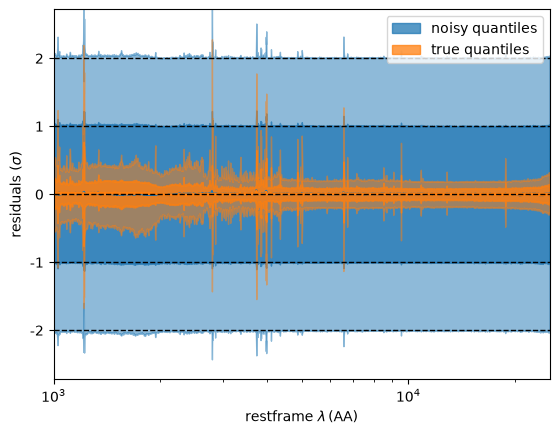

average absolute deviation of noiseless residuals from zero (in units of sigma): 0.10411891341209412


In [7]:
N_EVAL = 1_000_000 # how many test samples to use for evaluation

# quantile bands of reconstruction residuals across wavelength bins

preds = batched(autoenc, fluxes[idx_test[:N_EVAL]])   # reconstructions, reused in the cells below
residuals = (fluxes[idx_test[:N_EVAL]] - preds) / errs[idx_test[:N_EVAL]]
raw_residuals = (noiseless_fluxes[idx_test[:N_EVAL]] - preds) / errs[idx_test[:N_EVAL]]

q_levels = torch.distributions.Normal(0, 1).cdf(torch.tensor([-3., -2., -1., 0., 1., 2., 3.]))
q = quantile_cols(residuals, q_levels).numpy()
q_raw = quantile_cols(raw_residuals, q_levels).numpy()

plt.figure()
hq1 = plt.plot(WAV, q[3], color='tab:blue')
hq3 = plt.fill_between(WAV, q[1], q[5], alpha=0.5, color='tab:blue')
hq2 = plt.fill_between(WAV, q[2], q[4], alpha=0.75, color='tab:blue')
hq1r = plt.plot(WAV, q_raw[3], color='tab:orange')
hq3r = plt.fill_between(WAV, q_raw[1], q_raw[5], alpha=0.5, color='tab:orange')
hq2r = plt.fill_between(WAV, q_raw[2], q_raw[4], alpha=0.75, color='tab:orange')
plt.hlines((-3,-2,-1,0,1,2,3), WAV[0], WAV[-1], color='k', ls='--', lw=1)

plt.ylim((-np.e,np.e)), plt.xlim((WAV[0], WAV[-1]))
plt.xscale('log')
plt.yticks([-2, -1, 0, 1, 2], [-2, -1, 0, 1, 2])
plt.xlabel(r'restframe $\lambda\,(\text{\AA})$'), plt.ylabel(r'residuals ($\sigma$)')
plt.legend(handles=[hq2,hq2r], labels=[r'noisy quantiles', r'true quantiles'], loc='upper right')
plt.show()


# average deviation
print('average absolute deviation of noiseless residuals from zero (in units of sigma):', 
    raw_residuals.abs().mean(dim=0).mean().item())

### Reconstruction loss distribution

Distribution of per-spectrum reconstruction losses against the noisy inputs and the ground truth (Fig. 2).

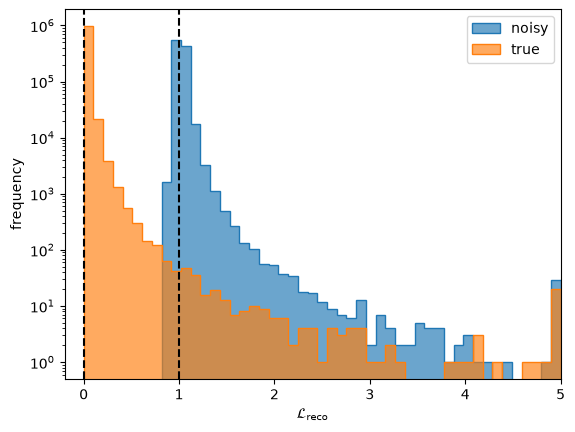

average reconstruction loss: 1.0215248
average noiseless reconstruction loss: 0.027438778
fraction of spectra with reconstruction loss < 1: 0.326886
fraction of spectra with noiseless reconstruction loss < 1: 0.999755
fraction of spectra with noiseless reconstruction loss < 0.1: 0.970415


In [8]:
# preds: AE reconstructions of the test set, computed in the cell above
losses = torch.square((fluxes[idx_test[:N_EVAL]] - preds) / errs[idx_test[:N_EVAL]]).mean(dim=1).detach().numpy()
losses_raw = torch.square((noiseless_fluxes[idx_test[:N_EVAL]] - preds) / errs[idx_test[:N_EVAL]]).mean(dim=1).detach().numpy()

plt.figure()
bins=np.linspace(0,5,50)
plt.hist(losses.clip(max=bins[-1]), bins=bins, 
         histtype='stepfilled', facecolor=mpl.colors.to_hex(mpl.colors.to_rgba('tab:blue', alpha=0.66), keep_alpha=True), edgecolor='tab:blue', label='noisy')
plt.hist(losses_raw.clip(max=bins[-1]), bins=bins, 
         histtype='stepfilled', facecolor=mpl.colors.to_hex(mpl.colors.to_rgba('tab:orange', alpha=0.66), keep_alpha=True), edgecolor='tab:orange', label='true')
plt.axvline(1, color='k', linestyle='--')
plt.axvline(0, color='k', linestyle='--')

plt.xlim((bins[0]-0.2, bins[-1]))
plt.yscale('log')
plt.xlabel(r'$\mathcal{L}_\mathrm{reco}$'), plt.ylabel(r'frequency')
plt.legend()
plt.show()

print('average reconstruction loss:', losses.mean())
print('average noiseless reconstruction loss:', losses_raw.mean())

print('fraction of spectra with reconstruction loss < 1:', (losses < 1).mean())
print('fraction of spectra with noiseless reconstruction loss < 1:', (losses_raw < 1).mean())
print('fraction of spectra with noiseless reconstruction loss < 0.1:', (losses_raw < 0.1).mean())

### Photometric accuracy

AB magnitudes calculated from integrating the reconstructed versus the true spectra to quantify the impact of reconstruction errors on photometry.

In [9]:
# magnitude accuracy
test_mags = util.ab_mag(noiseless_fluxes[idx_test[:N_EVAL]] / (1 + z[idx_test[:N_EVAL],None]) * luminosities[idx_test[:N_EVAL],None], 
                        WAV * (1+z[idx_test[:N_EVAL],None]), 
                        bands='ugrizYJHK')

torch.cuda.empty_cache()
rec_mags = util.ab_mag(preds / (1 + z[idx_test[:N_EVAL],None]) * luminosities[idx_test[:N_EVAL],None], 
                        (WAV * (1+z[idx_test[:N_EVAL],None])), 
                        bands='ugrizYJHK')

for b in ['u','g','r','i','z','Y','J','H','K']:
    print(f"Filter {b}: mean = {torch.mean(test_mags[b] - rec_mags[b]):.4f}, std = {torch.std(test_mags[b] - rec_mags[b]):.4f}")

Filter u: mean = -0.0005, std = 0.0122
Filter g: mean = -0.0003, std = 0.0094
Filter r: mean = -0.0004, std = 0.0098
Filter i: mean = -0.0001, std = 0.0103
Filter z: mean = -0.0005, std = 0.0106
Filter Y: mean = -0.0005, std = 0.0106
Filter J: mean = -0.0005, std = 0.0106
Filter H: mean = -0.0001, std = 0.0103
Filter K: mean = 0.0001, std = 0.0105


### Latent encoding

Encode the full dataset into (AE latents, $z$, $l^*$) — the training input for
`train_flow.py`.

In [10]:
# encode the full dataset into (AE latents, z, l*) for training the flow
# the file is provided on Zenodo, uncomment to re-generate
# torch.save(torch.cat((batched(autoenc.model.encode, fluxes), 
#                       z.unsqueeze(1), (luminosities*1e17).log10().unsqueeze(1)),dim=1), 
#            DATAPATH + 'sim_sample_AEncoded+z+L.pt')

## Normalising flow

A masked autoregressive flow models the joint distribution of the 6 AE latents,
redshift $z$, and rescaled log-luminosity $l^*$. Together with the AE decoder it forms
the full generative model: sampling the flow and decoding yields new galaxy spectra
with redshifts and luminosities (paper Sect. 3.2–3.3). We load the published checkpoint
and draw one realisation the size of the test set.

In [11]:

flow = models.build_paper_flow()

# load the published flow checkpoint
flow = models.LFlow.load_from_checkpoint(
    FILEPATH + 'models/Flow_MAF_t5_h256x256x256_Adam_lr0.001_reduce_1000k_GalSBIUspec1M_restframe/version_0/best.ckpt',
    model=flow,
).eval().to(device)

# draw one PAE realisation of the same size as the test set
# (calling a zuko flow returns a torch distribution)
samples = flow(None).sample((len(idx_test),))

# decode latents (columns 0-5) to rest-frame spectra; columns 6 and 7 hold z and l*
sampled_spectra = batched(autoenc.model.decode, samples[:,:6])
sampled_z = samples[:,6].detach().cpu()
sampled_L = samples[:,7].detach().cpu()

# uncomment to regenerate the PAE_sample_* files provided on Zenodo
# torch.save(sampled_spectra, DATAPATH+'PAE_sample_sed.pt')
# torch.save(sampled_z, DATAPATH+'PAE_sample_z.pt')
# torch.save(sampled_L, DATAPATH+'PAE_sample_L.pt')

### Latent-space distribution

Corner plot of flow samples versus the encoded test set (Fig. 5).

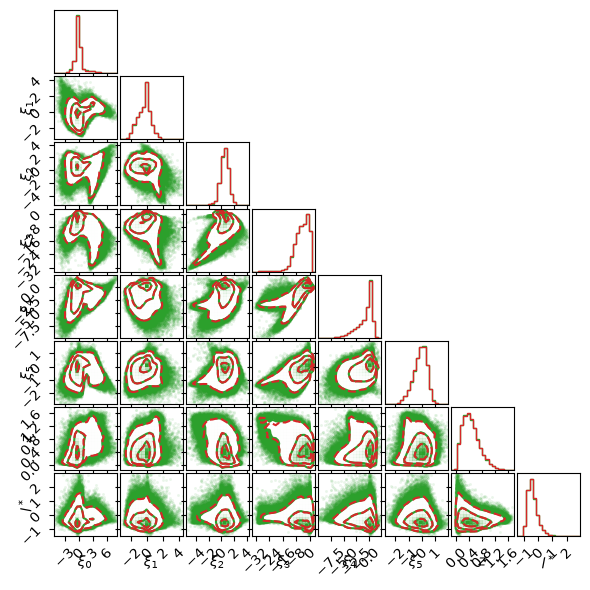

In [12]:
N_EVAL = 1_000_000 # how many test samples to use for evaluation


# axis ranges: 0.01-99.99 percentiles padded by 10%; contour levels at 1/2/3 sigma
ranges = [(l.item()-0.1*(u.item()-l.item()),u.item()+0.1*(u.item()-l.item())) for l,u in torch.quantile(samples,torch.tensor([0.0001,0.9999]).to(device),dim=0).T.cpu()]
levels = [(1-np.exp(-s**2/2)) for s in (1,2,3,)]

fig = plt.figure(figsize=(6,6))
corner.corner(samples[:N_EVAL].detach().cpu().numpy(), 
              fig=fig, color='tab:green', levels=levels, range=ranges, 
              labels=[rf'$\xi_{i}$' for i in range(N_LATENT)]+[r'$z$',r'$l^*$'])
latents = torch.cat((batched(autoenc.model.encode, fluxes[idx_test]), 
                     z[idx_test,None], 
                     (luminosities[idx_test,None]*1e17).log10()),dim=1)
corner.corner(latents[:N_EVAL].detach().cpu().numpy(), 
              fig=fig, color='tab:red', levels=levels, range=ranges, 
              plot_datapoints=False, plot_density=False, no_fill_contours=True, contour_kwargs={'linestyles':'dashed'})
plt.tight_layout()
fig.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()

### Sampled spectra

Population quantiles and example spectra of the PAE sample, compared to the quantiles
of the noiseless test set.

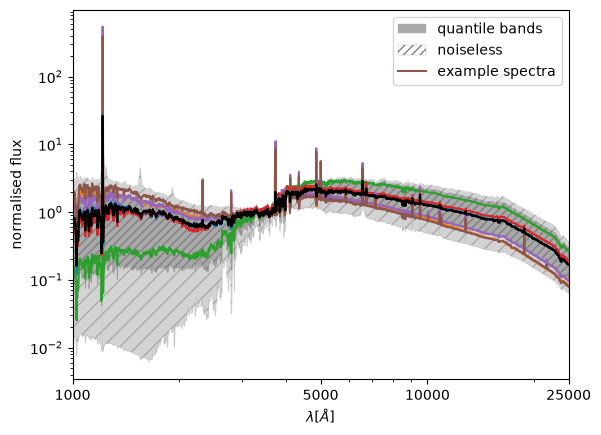

In [13]:
# plot example spectra from samples

q1, q2, q3, q4, q5 = quantile_cols(sampled_spectra[:N_EVAL], [0.025, 0.16, 0.5, 0.84, 0.975])
qo1, qo2, qo3, qo4, qo5 = quantile_cols(noiseless_fluxes[idx_test[:N_EVAL]], [0.025, 0.16, 0.5, 0.84, 0.975])

plt.figure()
l1 = plt.plot(WAV,q3,
              c='k', zorder=10)
l2 = plt.fill_between(WAV, q1, q5, 
                      facecolor='lightgray', edgecolor='lightgray', lw=.25, alpha=1.)
l3 = plt.fill_between(WAV, q2, q4, 
                      facecolor='darkgray', edgecolor='darkgray', lw=.25, alpha=1.)
lo1 = plt.plot(WAV,qo3,
               c='k', ls='--', zorder=10)
lo2 = plt.fill_between(WAV, qo1, qo5, 
                       hatch='//',
                       facecolor='none', edgecolor='darkgray', lw=.25, ls='--', alpha=1.)
lo3 = plt.fill_between(WAV, qo2, qo4, 
                       hatch='////',
                       facecolor='none', edgecolor='gray', lw=.25, ls='--', alpha=1.)

for i in np.random.randint(0,len(sampled_spectra), size=6):
    li, = plt.plot(WAV,sampled_spectra[i].detach().cpu().numpy())

plt.yscale('log'), plt.xscale('log')
plt.xlim(WAV[0], WAV[-1])
plt.xticks([1000, 5000, 10000, 25000],['1000', '5000', '10000', '25000'])
plt.xlabel(r'$\lambda [\AA]$'), plt.ylabel('normalised flux')
plt.legend(handles=[l3, lo3, li],
           labels=['quantile bands', 'noiseless', 'example spectra'],
           ncol=1, loc='upper right')
plt.show()

### Pixel-wise PIT

Probability integral transform of the PAE sample quantiles under the test-set
distribution, per wavelength bin (Fig. 6). Horizontal lines indicate perfect
agreement.

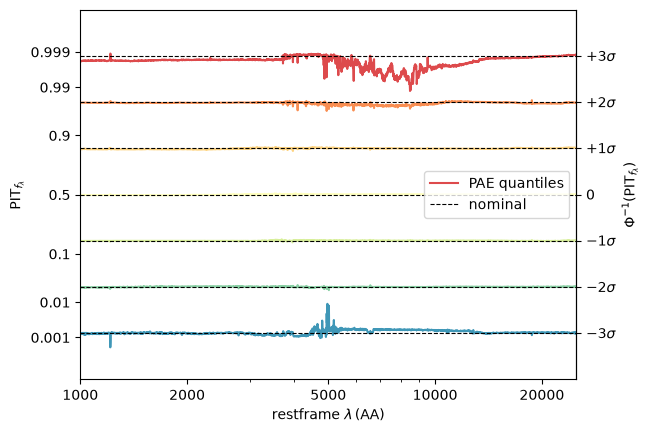

In [14]:
# illustrate quantile deviations with dual PIT and probit

sigmas = np.array([-3, -2, -1, 0, 1, 2, 3])
q_levels = norm.cdf(sigmas)
pit = util.ECDF_vectorized(noiseless_fluxes[idx_test[:N_EVAL]].detach().numpy())
q_sampled = pit(np.quantile(sampled_spectra[:N_EVAL].cpu().detach().numpy(),
                             q_levels, axis=0)).clip(1e-6, 1 - 1e-6)

plt.figure()
for ql, ql_sampled in zip(q_levels, q_sampled):
    # colour each quantile line by its sigma level, symmetric around the colormap centre
    ls, = plt.plot(WAV, norm.ppf(ql_sampled), 
                  color=mpl.colormaps['Spectral'](0.5 - norm.ppf(ql) / (len(q_levels)+1) * 0.99))
l = plt.hlines(norm.ppf(q_levels), WAV[0], WAV[-1], color='k', ls='--', lw=.8)

plt.ylim((-4, 4)), plt.xlim((WAV[0], WAV[-1]))
plt.xscale('log'), 
plt.xticks([1000, 2000, 5000, 10000, 20000],['1000', '2000', '5000', '10000', '20000'])
plt.yticks(norm.ppf(np.array([1e-3, 1e-2, 0.1, 0.5, 0.9, 0.99, 0.999])), ['0.001', '0.01', '0.1', '0.5', '0.9', '0.99', '0.999'])
plt.xlabel(r'restframe $\lambda\,(\text{\AA})$'), plt.ylabel(r'$\mathrm{PIT}_{f_\lambda}$')

sec = plt.gca().secondary_yaxis('right', functions=(lambda v: v, lambda v: v))
sec.set_yticks(sigmas)
sec.set_yticklabels([r'$0$' if s == 0 else rf'${s:+d}\sigma$' for s in sigmas])
sec.set_ylabel(r'$\Phi^{-1}(\mathrm{PIT}_{f_\lambda})$')

plt.legend(handles=[ls, l], labels=['PAE quantiles', 'nominal'],
           loc='center right')
plt.show()